In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful ✓')

All imports successful ✓


In [9]:
import pandas as pd

df = pd.read_csv('../Data/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [10]:
print('Column types:')

print('\nMissing values:')
print(df.isnull().sum())

Column types:

Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64


In [16]:
print(df.columns.tolist())

['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


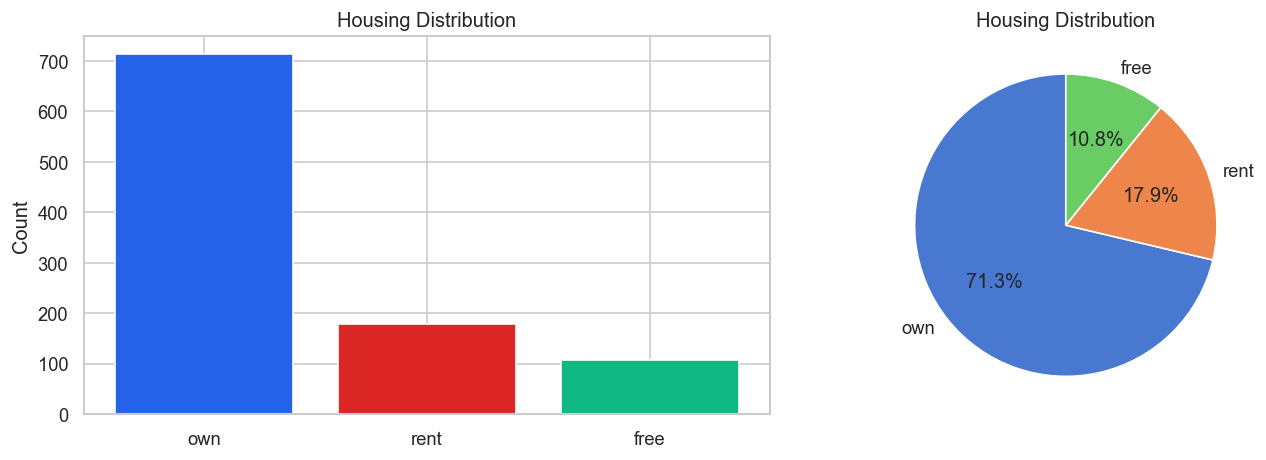

In [18]:
import matplotlib.pyplot as plt

counts = df['Housing'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.index, counts.values,
            color=['#2563EB', '#DC2626', '#10B981'])

axes[0].set_title('Housing Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            startangle=90)

axes[1].set_title('Housing Distribution')

plt.tight_layout()
plt.show()

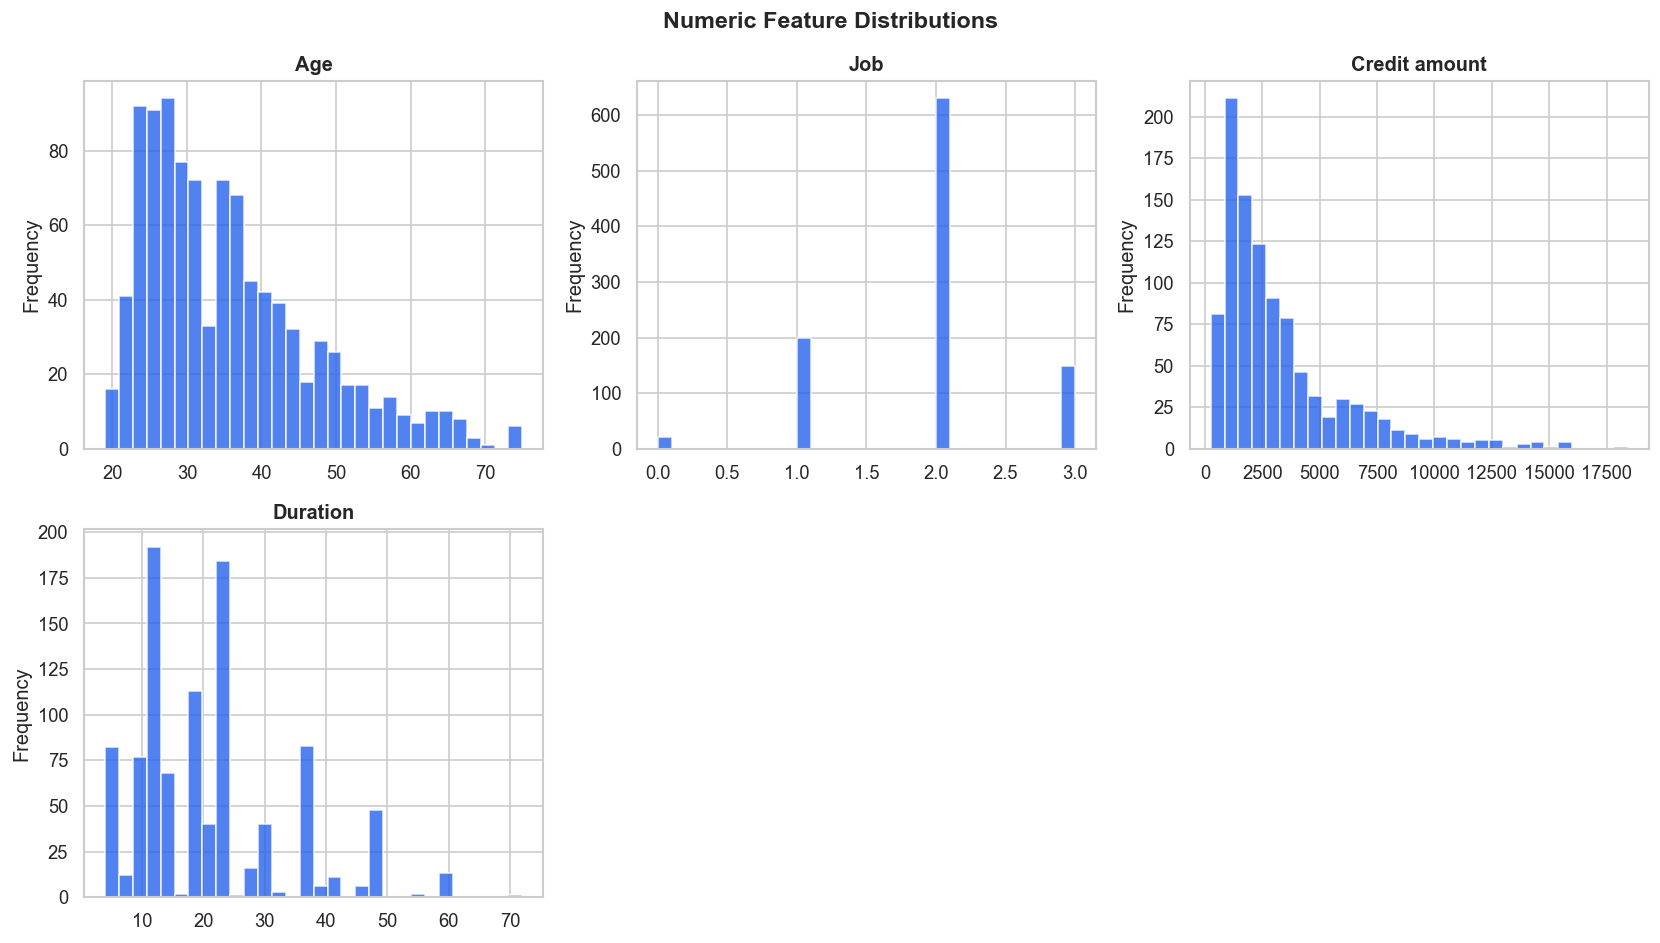

In [19]:
import matplotlib.pyplot as plt
from pathlib import Path

# Get numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Remove index column if present
if 'Unnamed: 0' in numeric_cols:
    numeric_cols.remove('Unnamed: 0')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:6]):
    axes[i].hist(df[col].dropna(),
                 bins=30,
                 color='#2563EB',
                 edgecolor='white',
                 alpha=0.8)

    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(numeric_cols[:6]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions',
             fontsize=14,
             fontweight='bold')

plt.tight_layout()

# Create output directory if needed
Path('../outputs/plots').mkdir(parents=True, exist_ok=True)

plt.savefig('../outputs/plots/feature_distributions.png',
            bbox_inches='tight')

plt.show()

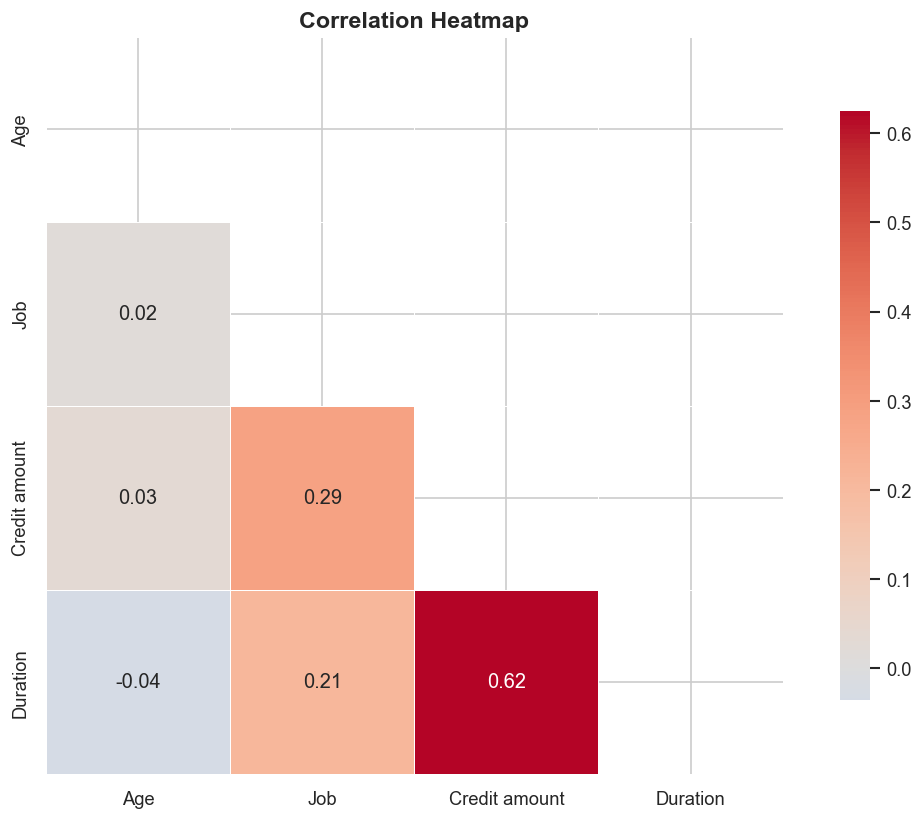

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# numeric columns only
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# remove index column if present
if 'Unnamed: 0' in numeric_cols:
    numeric_cols.remove('Unnamed: 0')

# correlation matrix
numeric_df = df[numeric_cols].copy()
corr = numeric_df.corr()

# plot
plt.figure(figsize=(10, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()

Path('../outputs/plots').mkdir(parents=True, exist_ok=True)
plt.savefig('../outputs/plots/correlation_heatmap.png', bbox_inches='tight')

plt.show()

In [21]:
def clean_data(df):
    df = df.copy()

    # remove index column
    if 'Unnamed: 0' in df.columns:
        df.drop('Unnamed: 0', axis=1, inplace=True)

    # fill missing values (common in this dataset)
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

    return df

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def encode_and_scale(df):
    df = df.copy()

    # separate features
    X = df.copy()

    # categorical + numeric columns
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    num_cols = X.select_dtypes(include='number').columns.tolist()

    # remove unwanted index column if present
    if 'Unnamed: 0' in num_cols:
        num_cols.remove('Unnamed: 0')

    # preprocessing
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    X_processed = preprocessor.fit_transform(X)

    # ⚠️ No real target exists in your dataset
    y = None

    return X_processed, y, preprocessor

In [24]:
from sklearn.model_selection import train_test_split

def get_train_test_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y if y is not None else None
    )
    return X_train, X_test, y_train, y_test

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def train_all_models(X_train, y_train):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    trained_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        trained_models[name] = model

        print(f"{name} trained ✔")

    return trained_models

Logistic Regression trained ✔
Random Forest trained ✔

RESULTS:
                     Accuracy        F1
Logistic Regression      0.98  0.979798
Random Forest            1.00  1.000000


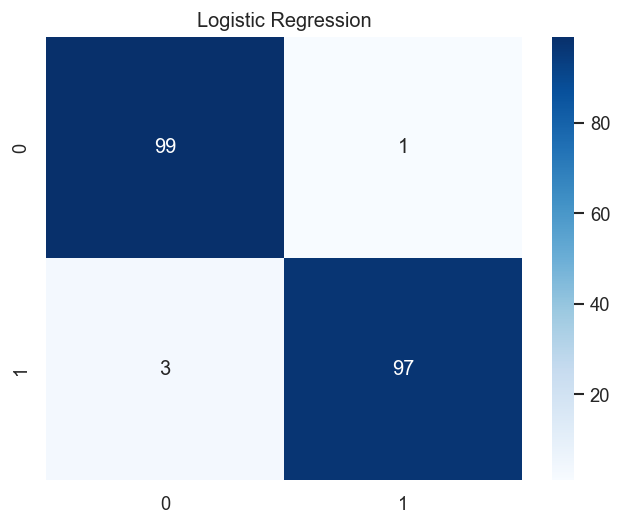

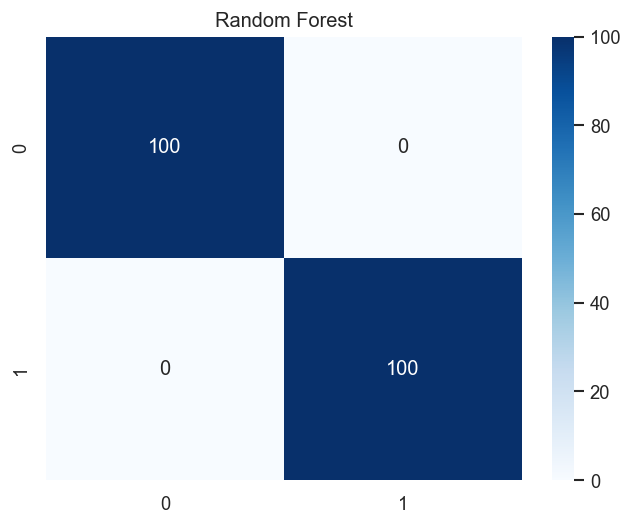

<Figure size 768x576 with 0 Axes>

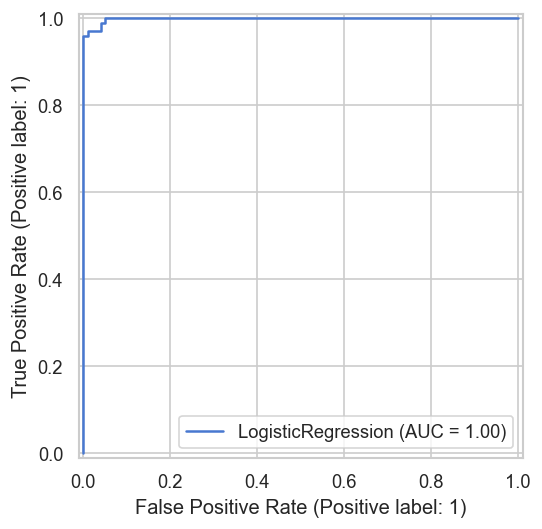

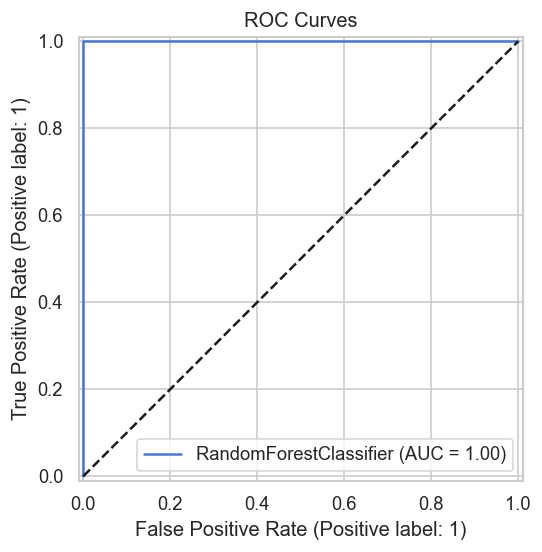

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, RocCurveDisplay

# ---------------- LOAD ----------------
df = df.copy()
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# ---------------- TARGET ----------------
df['Risk'] = (df['Credit amount'] > df['Credit amount'].median()).astype(int)

X = df.drop('Risk', axis=1)
y = df['Risk']

# ---------------- SPLIT FIRST (FIX IMPORTANT) ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------- PREPROCESS (fit ONLY on train) ----------------
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train = preprocess.fit_transform(X_train)
X_test = preprocess.transform(X_test)

# ---------------- MODELS ----------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

    print(f"{name} trained ✔")

# ---------------- RESULTS ----------------
print("\nRESULTS:")
print(pd.DataFrame(results).T)

# ---------------- CONFUSION MATRIX ----------------
for name, model in models.items():
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.show()

# ---------------- ROC CURVE ----------------
plt.figure()
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.show()


--- MODEL COMPARISON ---
Accuracy  : 1.0000 → 1.0000 = 0.0000
F1        : 1.0000 → 1.0000 = 0.0000
ROC-AUC   : 1.0000 → 1.0000 = 0.0000


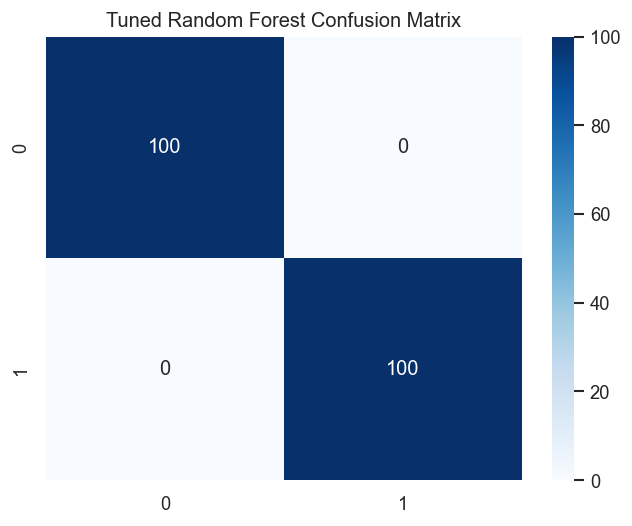

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# ---------------- LOAD ----------------
df = df.copy()
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# ---------------- CREATE TARGET ----------------
df['Risk'] = (df['Credit amount'] > df['Credit amount'].median()).astype(int)

X = df.drop('Risk', axis=1)
y = df['Risk']

# ---------------- SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------- PREPROCESS ----------------
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train = preprocess.fit_transform(X_train)
X_test = preprocess.transform(X_test)

# ---------------- BASE MODEL ----------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    }

base_results = evaluate(rf, X_test, y_test)

# ---------------- HYPERPARAMETER TUNING ----------------
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
best_rf = search.best_estimator_

# ---------------- TUNED MODEL EVALUATION ----------------
tuned_results = evaluate(best_rf, X_test, y_test)

# ---------------- COMPARISON ----------------
print("\n--- MODEL COMPARISON ---")
for metric in base_results:
    diff = tuned_results[metric] - base_results[metric]
    arrow = "▲" if diff > 0 else ("▼" if diff < 0 else "=")

    print(f"{metric:<10}: {base_results[metric]:.4f} → {tuned_results[metric]:.4f} {arrow} {abs(diff):.4f}")

# ---------------- CONFUSION MATRIX (BEST MODEL) ----------------
cm = confusion_matrix(y_test, best_rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [29]:
import os
import joblib

# create folder if not exists
os.makedirs("outputs/models", exist_ok=True)

def save_model(model, filename):
    path = f"outputs/models/{filename}"
    joblib.dump(model, path)
    print(f"Saved: {path}")

# ---------------- SAVE BEST MODEL ----------------
save_model(best_rf, "best_random_forest.pkl")

# ---------------- SAVE ALL MODELS ----------------
for name, model in models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    save_model(model, filename)

print("\nAll models saved to outputs/models/ ✓")

Saved: outputs/models/best_random_forest.pkl
Saved: outputs/models/logistic_regression.pkl
Saved: outputs/models/random_forest.pkl

All models saved to outputs/models/ ✓
